In [ ]:
!pip install CoolProp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 48.3 MB/s eta 0:00:00


In [ ]:
import math

try:
    from CoolProp.CoolProp import PropsSI
except ImportError:
    raise SystemExit("Install CoolProp first: pip install CoolProp")

REF = "R404A"  # change if needed

# -----------------------
# Assumed inputs (the only things you 'assume')
# -----------------------
Te_MT_C = 5.0       # Evap 1 SST (°C)
Te_LT_C = -30.0     # Evap 2 SST (°C)
Tc_C    = 45.0      # Condensing temperature SDT (°C)

dTsh_MT = 7.0       # superheat Evap 1 (K)
dTsh_LT = 7.0       # superheat Evap 2 (K)
dTsc    = 5.0       # subcooling after condenser (K)

eta_is_1 = 0.75     # Compressor 1 isentropic efficiency
eta_is_2 = 0.75     # Compressor 2 isentropic efficiency

Q_MT_kW = 100.0     # load on Evap 1 (kW)
Q_LT_kW = 50.0      # load on Evap 2 (kW)

# -----------------------
# Unit helpers
# -----------------------
def C_to_K(Tc): return Tc + 273.15
def kW_to_W(x): return x * 1000.0

Te_MT = C_to_K(Te_MT_C)
Te_LT = C_to_K(Te_LT_C)
Tc    = C_to_K(Tc_C)

Q_MT = kW_to_W(Q_MT_kW)
Q_LT = kW_to_W(Q_LT_kW)

# -----------------------
# Key rule: pressures come from saturation temperatures
# -----------------------
P_i = PropsSI("P", "T", Te_MT, "Q", 1, REF)  # intermediate pressure = Psat at Evap1 SST
P_l = PropsSI("P", "T", Te_LT, "Q", 1, REF)  # low pressure = Psat at Evap2 SST
P_h = PropsSI("P", "T", Tc,    "Q", 0, REF)  # high pressure = Psat at condensing temp

# -----------------------
# State 4: condenser outlet (subcooled liquid)
# -----------------------
T4 = Tc - dTsc
h4 = PropsSI("H", "T", T4, "P", P_h, REF)
s4 = PropsSI("S", "T", T4, "P", P_h, REF)

# Split line states (5 and 7): same as 4 (no heat/work in split)
h5 = h4; P5 = P_h
h7 = h4; P7 = P_h

# -----------------------
# Expansion valves (isoenthalpic)
# -----------------------
# 5 -> 6 (to P_i)
P6 = P_i
h6 = h5
T6 = PropsSI("T", "P", P6, "H", h6, REF)
s6 = PropsSI("S", "P", P6, "H", h6, REF)

# 7 -> 8 (to P_l)
P8 = P_l
h8 = h7
T8 = PropsSI("T", "P", P8, "H", h8, REF)
s8 = PropsSI("S", "P", P8, "H", h8, REF)

# Optional qualities (only meaningful if in 2-phase region)
def safe_quality(P, h):
    try:
        x = PropsSI("Q", "P", P, "H", h, REF)
        if math.isnan(x) or x < 0 or x > 1:
            return None
        return x
    except:
        return None

x6 = safe_quality(P6, h6)
x8 = safe_quality(P8, h8)

# -----------------------
# Evaporator outlets (superheated vapor)
# -----------------------
# State 1 (Evap1 outlet): at P_i, T = Te_MT + superheat
T1 = Te_MT + dTsh_MT
P1 = P_i
h1 = PropsSI("H", "T", T1, "P", P1, REF)
s1 = PropsSI("S", "T", T1, "P", P1, REF)

# State 9 (Evap2 outlet): at P_l, T = Te_LT + superheat
T9 = Te_LT + dTsh_LT
P9 = P_l
h9 = PropsSI("H", "T", T9, "P", P9, REF)
s9 = PropsSI("S", "T", T9, "P", P9, REF)

# -----------------------
# Mass flow rates from evaporator energy balances
# -----------------------
m_MT = Q_MT / (h1 - h6)
m_LT = Q_LT / (h9 - h8)
m_tot = m_MT + m_LT

# -----------------------
# Compressor 2: 9 -> 10 (to P_i)
# -----------------------
P10 = P_i
h10s = PropsSI("H", "P", P10, "S", s9, REF)  # isentropic
h10  = h9 + (h10s - h9) / eta_is_2
T10  = PropsSI("T", "P", P10, "H", h10, REF)
s10  = PropsSI("S", "P", P10, "H", h10, REF)

# -----------------------
# Mixer: (1 and 10) -> 2 at P_i (adiabatic)
# -----------------------
P2 = P_i
h2 = (m_MT*h1 + m_LT*h10) / m_tot
T2 = PropsSI("T", "P", P2, "H", h2, REF)
s2 = PropsSI("S", "P", P2, "H", h2, REF)

# -----------------------
# Compressor 1: 2 -> 3 (to P_h)
# -----------------------
P3 = P_h
h3s = PropsSI("H", "P", P3, "S", s2, REF)
h3  = h2 + (h3s - h2) / eta_is_1
T3  = PropsSI("T", "P", P3, "H", h3, REF)
s3  = PropsSI("S", "P", P3, "H", h3, REF)

# -----------------------
# Condenser heat rejection + powers + COP
# -----------------------
Q_cond = m_tot * (h3 - h4)
W2 = m_LT * (h10 - h9)
W1 = m_tot * (h3 - h2)
COP = (Q_MT + Q_LT) / (W1 + W2)

# -----------------------
# Print key results
# -----------------------
print("---- Pressures (bar) ----")
print(f"P_l = {P_l/1e5:.3f} bar, P_i = {P_i/1e5:.3f} bar, P_h = {P_h/1e5:.3f} bar")

print("\n---- Mass flows (kg/s) ----")
print(f"m_MT = {m_MT:.4f}, m_LT = {m_LT:.4f}, m_tot = {m_tot:.4f}")

print("\n---- Powers / COP ----")
print(f"W1 = {W1/1000:.2f} kW, W2 = {W2/1000:.2f} kW")
print(f"Q_cond = {Q_cond/1000:.2f} kW")
print(f"COP = {COP:.3f}")

print("\n---- Qualities (if 2-phase) ----")
print(f"x6 = {x6}, x8 = {x8}")

# If you want a neat state table dump, build a dict:
states = {
    1: (T1, P1, h1, s1, m_MT, None),
    2: (T2, P2, h2, s2, m_tot, None),
    3: (T3, P3, h3, s3, m_tot, None),
    4: (T4, P_h, h4, s4, m_tot, None),
    5: (T4, P_h, h5, s4, m_MT, None),
    6: (T6, P6, h6, s6, m_MT, x6),
    7: (T4, P_h, h7, s4, m_LT, None),
    8: (T8, P8, h8, s8, m_LT, x8),
    9: (T9, P9, h9, s9, m_LT, None),
    10:(T10,P10,h10,s10,m_LT, None),
}

print("\nState:   T[K]     P[bar]   h[kJ/kg]  s[kJ/kg-K]  m[kg/s]   x")
for k in sorted(states):
    T,P,h,s,m,x = states[k]
    print(f"{k:>2}:   {T:7.2f}  {P/1e5:7.3f}  {h/1000:8.2f}   {s/1000:9.4f}   {m:7.4f}   {x}")

---- Pressures (bar) ----
P_l = 2.022 bar, P_i = 7.018 bar, P_h = 20.595 bar

---- Mass flows (kg/s) ----
m_MT = 0.8656, m_LT = 0.5239, m_tot = 1.3895

---- Powers / COP ----
W1 = 42.21 kW, W2 = 18.00 kW
Q_cond = 210.22 kW
COP = 2.491

---- Qualities (if 2-phase) ----
x6 = 0.3307994522807019, x8 = 0.5296482461779346

State:   T[K]     P[bar]   h[kJ/kg]  s[kJ/kg-K]  m[kg/s]   x
 1:    285.15    7.018    375.40      1.6308    0.8656   None
 2:    290.51    7.018    380.79      1.6495    1.3895   None
 3:    340.23   20.595    411.17      1.6720    1.3895   None
 4:    313.15   20.595    259.88      1.1995    1.3895   None
 5:    313.15   20.595    259.88      1.1995    0.8656   None
 6:    277.82    7.018    259.88      1.2154    0.8656   0.3307994522807019
 7:    313.15   20.595    259.88      1.1995    0.5239   None
 8:    242.84    2.022    259.88      1.2578    0.5239   0.5296482461779346
 9:    250.15    2.022    355.32      1.6506    0.5239   None
10:    299.45    7.018    389.69  


==== Pressures computed from saturation temps ====
P_l = 2.022 bar, P_i = 7.018 bar, P_h = 20.595 bar

==== Mass flows ====
m_MT = 0.86561 kg/s, m_LT = 0.52387 kg/s, m_tot = 1.38948 kg/s

==== Performance ====
W1 (Comp1) = 42.21 kW
W2 (Comp2) = 18.00 kW
Q_cond     = 210.22 kW
COP        = 2.491

==== State table (all streams) ====
 State        T_C     P_bar     h_kJkg  s_kJkgK   m_kgps        x
     1  12.000000  7.017964 375.401111 1.630812 0.865611      NaN
     2  17.355792  7.017964 380.786555 1.649523 1.389478      NaN
     3  67.079190 20.594795 411.167235 1.672047 1.389478      NaN
     4  40.000000 20.594795 259.875720 1.199527 1.389478      NaN
     5  40.000000 20.594795 259.875720 1.199527 0.865611      NaN
     6   4.668830  7.017964 259.875720 1.215396 0.865611 0.330799
     7  40.000000 20.594795 259.875720 1.199527 0.523867      NaN
     8 -30.310391  2.022337 259.875720 1.257771 0.523867 0.529648
     9 -23.000000  2.022337 355.319742 1.650580 0.523867      NaN
    10

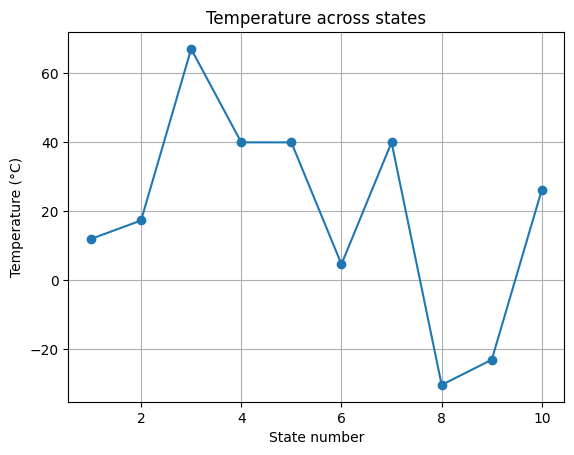

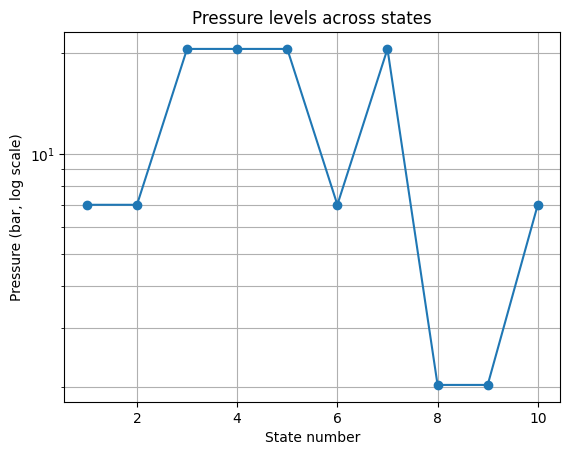

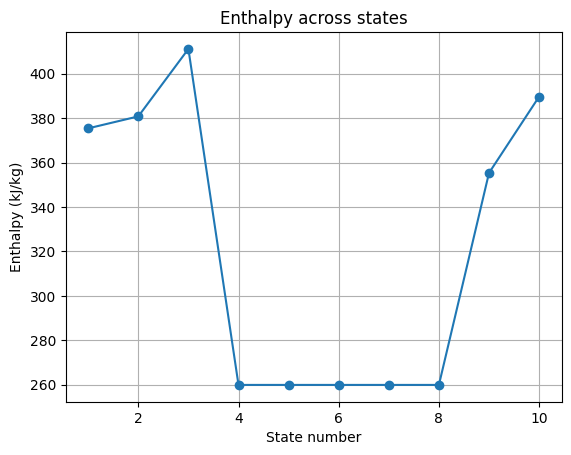

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# USER INPUTS (ASSUMED)
# =========================
REF = "R404A"         # change if assigned
Te_MT_C = 5.0         # Evap-1 SST (°C)  (above zero)
Te_LT_C = -30.0       # Evap-2 SST (°C)  (below zero)
Tc_C    = 45.0        # Condensing temperature SDT (°C)

dTsh_MT = 7.0         # superheat Evap-1 outlet (K)
dTsh_LT = 7.0         # superheat Evap-2 outlet (K)
dTsc    = 5.0         # subcooling at condenser outlet (K)

eta_is_1 = 0.75       # Compressor 1 isentropic efficiency (2->3)
eta_is_2 = 0.75       # Compressor 2 isentropic efficiency (9->10)

Q_MT_kW = 100.0       # Evap-1 load (kW)
Q_LT_kW = 50.0        # Evap-2 load (kW)

# =========================
# HELPERS
# =========================
def C_to_K(Tc): return Tc + 273.15
def K_to_C(Tk): return Tk - 273.15
def kW_to_W(x): return x * 1000.0

def Psat_from_T(T, Q):
    # Q=0 bubble, Q=1 dew (for blends, dew at evap outlet is common)
    return PropsSI("P", "T", T, "Q", Q, REF)

def props_TP(T, P):
    h = PropsSI("H", "T", T, "P", P, REF)
    s = PropsSI("S", "T", T, "P", P, REF)
    return h, s

def props_PH(P, h):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def H_from_PS(P, s):
    return PropsSI("H", "P", P, "S", s, REF)

def safe_quality_PH(P, h):
    # Only meaningful if the state is in the two-phase region
    try:
        x = PropsSI("Q", "P", P, "H", h, REF)
        if math.isnan(x) or x < 0 or x > 1:
            return None
        return float(x)
    except Exception:
        return None

# =========================
# SIMULATION (ALGORITHM FROM REPORT)
# =========================
Te_MT = C_to_K(Te_MT_C)
Te_LT = C_to_K(Te_LT_C)
Tc    = C_to_K(Tc_C)

Q_MT = kW_to_W(Q_MT_kW)
Q_LT = kW_to_W(Q_LT_kW)

# 1) Pressures from saturation temperatures
P_i = Psat_from_T(Te_MT, Q=1)  # Evap-1 pressure
P_l = Psat_from_T(Te_LT, Q=1)  # Evap-2 pressure
P_h = Psat_from_T(Tc,    Q=0)  # Condenser pressure (bubble)

# 2) State 4: condenser outlet (subcooled/compressed liquid)
T4 = Tc - dTsc
h4, s4 = props_TP(T4, P_h)

# 3) Split lines ( Degenerate States): 5 and 7 are BEFORE valves and at P_h
P5, T5, h5, s5 = P_h, T4, h4, s4
P7, T7, h7, s7 = P_h, T4, h4, s4

# 4) Throttles: isoenthalpic
# 5 -> 6 (to P_i)
P6, h6 = P_i, h5
T6, s6 = props_PH(P6, h6)
x6 = safe_quality_PH(P6, h6)

# 7 -> 8 (to P_l)
P8, h8 = P_l, h7
T8, s8 = props_PH(P8, h8)
x8 = safe_quality_PH(P8, h8)

# 5) Evaporator outlets (superheated)
# State 1 at (P_i, T = Te_MT + superheat)
T1 = Te_MT + dTsh_MT
P1 = P_i
h1, s1 = props_TP(T1, P1)

# State 9 at (P_l, T = Te_LT + superheat)
T9 = Te_LT + dTsh_LT
P9 = P_l
h9, s9 = props_TP(T9, P9)

# 6) Mass flows from loads
m_MT = Q_MT / (h1 - h6)
m_LT = Q_LT / (h9 - h8)
m_tot = m_MT + m_LT

# 7) Compressor 2: 9 -> 10 to P_i
P10 = P_i
h10s = H_from_PS(P10, s9)
h10  = h9 + (h10s - h9)/eta_is_2
T10, s10 = props_PH(P10, h10)

# 8) Mixer: 1 and 10 -> 2 at P_i (adiabatic)
P2 = P_i
h2 = (m_MT*h1 + m_LT*h10)/m_tot
T2, s2 = props_PH(P2, h2)

# 9) Compressor 1: 2 -> 3 to P_h
P3 = P_h
h3s = H_from_PS(P3, s2)
h3  = h2 + (h3s - h2)/eta_is_1
T3, s3 = props_PH(P3, h3)

# 10) Performance
Q_cond = m_tot*(h3 - h4)
W2 = m_LT*(h10 - h9)
W1 = m_tot*(h3 - h2)
COP = (Q_MT + Q_LT)/(W1 + W2)

# =========================
# OUTPUT: FULL STATE TABLE
# =========================
rows = [
    (1,  T1,  P1,  h1,  s1,  m_MT, None),
    (2,  T2,  P2,  h2,  s2,  m_tot, None),
    (3,  T3,  P3,  h3,  s3,  m_tot, None),
    (4,  T4,  P_h, h4,  s4,  m_tot, None),
    (5,  T5,  P5,  h5,  s5,  m_MT, None),
    (6,  T6,  P6,  h6,  s6,  m_MT, x6),
    (7,  T7,  P7,  h7,  s7,  m_LT, None),
    (8,  T8,  P8,  h8,  s8,  m_LT, x8),
    (9,  T9,  P9,  h9,  s9,  m_LT, None),
    (10, T10, P10, h10, s10, m_LT, None),
]
df = pd.DataFrame(rows, columns=["State","T_K","P_Pa","h_Jkg","s_JkgK","m_kgps","x"])
df["T_C"] = df["T_K"].map(K_to_C)
df["P_bar"] = df["P_Pa"]/1e5
df["h_kJkg"] = df["h_Jkg"]/1000
df["s_kJkgK"] = df["s_JkgK"]/1000
df = df[["State","T_C","P_bar","h_kJkg","s_kJkgK","m_kgps","x"]].sort_values("State")

print("\n==== Pressures computed from saturation temps ====")
print(f"P_l = {P_l/1e5:.3f} bar, P_i = {P_i/1e5:.3f} bar, P_h = {P_h/1e5:.3f} bar")

print("\n==== Mass flows ====")
print(f"m_MT = {m_MT:.5f} kg/s, m_LT = {m_LT:.5f} kg/s, m_tot = {m_tot:.5f} kg/s")

print("\n==== Performance ====")
print(f"W1 (Comp1) = {W1/1000:.2f} kW")
print(f"W2 (Comp2) = {W2/1000:.2f} kW")
print(f"Q_cond     = {Q_cond/1000:.2f} kW")
print(f"COP        = {COP:.3f}")

print("\n==== State table (all streams) ====")
print(df.to_string(index=False))

# Optional: save table
df.to_csv("state_table.csv", index=False)

# =========================
# PLOTS (relevant for Part 1 & 2)
# =========================
plt.figure()
plt.plot(df["State"], df["T_C"], marker="o")
plt.xlabel("State number")
plt.ylabel("Temperature (°C)")
plt.title("Temperature across states")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(df["State"], df["P_bar"], marker="o")
plt.xlabel("State number")
plt.ylabel("Pressure (bar, log scale)")
plt.title("Pressure levels across states")
plt.grid(True, which="both")
plt.show()

plt.figure()
plt.plot(df["State"], df["h_kJkg"], marker="o")
plt.xlabel("State number")
plt.ylabel("Enthalpy (kJ/kg)")
plt.title("Enthalpy across states")
plt.grid(True)
plt.show()


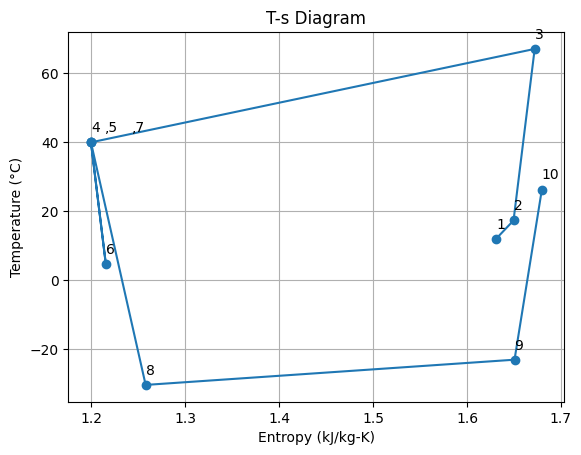

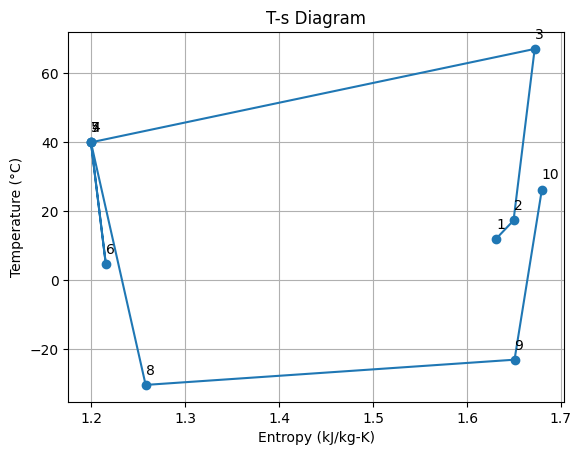

In [ ]:
# Re-run cell dmJAEle8yD0G to regenerate the correct 'df' for the T-s diagram
import math
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# USER INPUTS (ASSUMED)
# =========================
REF = "R404A"         # change if assigned
Te_MT_C = 5.0         # Evap-1 SST (°C)  (above zero)
Te_LT_C = -30.0       # Evap-2 SST (°C)  (below zero)
Tc_C    = 45.0        # Condensing temperature SDT (°C)

dTsh_MT = 7.0         # superheat Evap-1 outlet (K)
dTsh_LT = 7.0         # superheat Evap-2 outlet (K)
dTsc    = 5.0         # subcooling at condenser outlet (K)

eta_is_1 = 0.75       # Compressor 1 isentropic efficiency (2->3)
eta_is_2 = 0.75       # Compressor 2 isentropic efficiency (9->10)

Q_MT_kW = 100.0       # Evap-1 load (kW)
Q_LT_kW = 50.0        # Evap-2 load (kW)

# =========================
# HELPERS
# =========================
def C_to_K(Tc): return Tc + 273.15
def K_to_C(Tk): return Tk - 273.15
def kW_to_W(x): return x * 1000.0

def Psat_from_T(T, Q):
    # Q=0 bubble, Q=1 dew (for blends, dew at evap outlet is common)
    return PropsSI("P", "T", T, "Q", Q, REF)

def props_TP(T, P):
    h = PropsSI("H", "T", T, "P", P, REF)
    s = PropsSI("S", "T", T, "P", P, REF)
    return h, s

def props_PH(P, h):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def H_from_PS(P, s):
    return PropsSI("H", "P", P, "S", s, REF)

def safe_quality_PH(P, h):
    # Only meaningful if the state is in the two-phase region
    try:
        x = PropsSI("Q", "P", P, "H", h, REF)
        if math.isnan(x) or x < 0 or x > 1:
            return None
        return float(x)
    except Exception:
        return None

# =========================
# SIMULATION (ALGORITHM FROM REPORT)
# =========================
Te_MT = C_to_K(Te_MT_C)
Te_LT = C_to_K(Te_LT_C)
Tc    = C_to_K(Tc_C)

Q_MT = kW_to_W(Q_MT_kW)
Q_LT = kW_to_W(Q_LT_kW)

# 1) Pressures from saturation temperatures
P_i = Psat_from_T(Te_MT, Q=1)  # Evap-1 pressure
P_l = Psat_from_T(Te_LT, Q=1)  # Evap-2 pressure
P_h = Psat_from_T(Tc,    Q=0)  # Condenser pressure (bubble)

# 2) State 4: condenser outlet (subcooled/compressed liquid)
T4 = Tc - dTsc
h4, s4 = props_TP(T4, P_h)

# 3) Split lines ( Degenerate States): 5 and 7 are BEFORE valves and at P_h
P5, T5, h5, s5 = P_h, T4, h4, s4
P7, T7, h7, s7 = P_h, T4, h4, s4

# 4) Throttles: isoenthalpic
# 5 -> 6 (to P_i)
P6, h6 = P_i, h5
T6, s6 = props_PH(P6, h6)
x6 = safe_quality_PH(P6, h6)

# 7 -> 8 (to P_l)
P8, h8 = P_l, h7
T8, s8 = props_PH(P8, h8)
x8 = safe_quality_PH(P8, h8)

# 5) Evaporator outlets (superheated)
# State 1 at (P_i, T = Te_MT + superheat)
T1 = Te_MT + dTsh_MT
P1 = P_i
h1, s1 = props_TP(T1, P1)

# State 9 at (P_l, T = Te_LT + superheat)
T9 = Te_LT + dTsh_LT
P9 = P_l
h9, s9 = props_TP(T9, P9)

# 6) Mass flows from loads
m_MT = Q_MT / (h1 - h6)
m_LT = Q_LT / (h9 - h8)
m_tot = m_MT + m_LT

# 7) Compressor 2: 9 -> 10 to P_i
P10 = P_i
h10s = H_from_PS(P10, s9)
h10  = h9 + (h10s - h9)/eta_is_2
T10, s10 = props_PH(P10, h10)

# 8) Mixer: 1 and 10 -> 2 at P_i (adiabatic)
P2 = P_i
h2 = (m_MT*h1 + m_LT*h10)/m_tot
T2, s2 = props_PH(P2, h2)

# 9) Compressor 1: 2 -> 3 to P_h
P3 = P_h
h3s = H_from_PS(P3, s2)
h3  = h2 + (h3s - h2)/eta_is_1
T3, s3 = props_PH(P3, h3)

# 10) Performance
Q_cond = m_tot*(h3 - h4)
W2 = m_LT*(h10 - h9)
W1 = m_tot*(h3 - h2)
COP = (Q_MT + Q_LT)/(W1 + W2)

# =========================
# OUTPUT: FULL STATE TABLE
# =========================
rows = [
    (1,  T1,  P1,  h1,  s1,  m_MT, None),
    (2,  T2,  P2,  h2,  s2,  m_tot, None),
    (3,  T3,  P3,  h3,  s3,  m_tot, None),
    (4,  T4,  P_h, h4,  s4,  m_tot, None),
    (5,  T5,  P5,  h5,  s5,  m_MT, None),
    (6,  T6,  P6,  h6,  s6,  m_MT, x6),
    (7,  T7,  P7,  h7,  s7,  m_LT, None),
    (8,  T8,  P8,  h8,  s8,  m_LT, x8),
    (9,  T9,  P9,  h9,  s9,  m_LT, None),
    (10, T10, P10, h10, s10, m_LT, None),
]
df = pd.DataFrame(rows, columns=["State","T_K","P_Pa","h_Jkg","s_JkgK","m_kgps","x"])
df["T_C"] = df["T_K"].map(K_to_C)
df["P_bar"] = df["P_Pa"]/1e5
df["h_kJkg"] = df["h_Jkg"]/1000
df["s_kJkgK"] = df["s_JkgK"]/1000
df = df[["State","T_C","P_bar","h_kJkg","s_kJkgK","m_kgps","x"]].sort_values("State")

# Now plot the T-s diagram
plt.figure()
plt.plot(df["s_kJkgK"],df['T_C'], marker='o')
l=[]
df["State"]
for i in range(len(df["State"])):
  if (df["s_kJkgK"][i],df['T_C'][i]+3) not in l:
    plt.text(df["s_kJkgK"][i],df['T_C'][i]+3,df["State"][i])
  else:
    plt.text(df["s_kJkgK"][i]+i/100-0.1/i,df['T_C'][i]+3,f",{df["State"][i]}")
  l.append((df["s_kJkgK"][i],df['T_C'][i]+3))
plt.xlabel("Entropy (kJ/kg-K)")
plt.ylabel("Temperature (°C)")
plt.title("T-s Diagram")
plt.grid(True)
plt.show()
plt.plot(df["s_kJkgK"],df['T_C'], marker='o')
l=[]
df["State"]
for i in range(len(df["State"])):
  if (df["P_bar"][i],df['T_C'][i]+3) not in l:
    plt.text(df["s_kJkgK"][i],df['T_C'][i]+3,df["State"][i])
  else:
    plt.text(df["s_kJkgK"][i]+i/100-0.1/i,df['T_C'][i]+3,f",{df["State"][i]}")
  l.append((df["s_kJkgK"][i],df['T_C'][i]+3))
plt.xlabel("Entropy (kJ/kg-K)")
plt.ylabel("Temperature (°C)")
plt.title("T-s Diagram")
plt.grid(True)
plt.show()

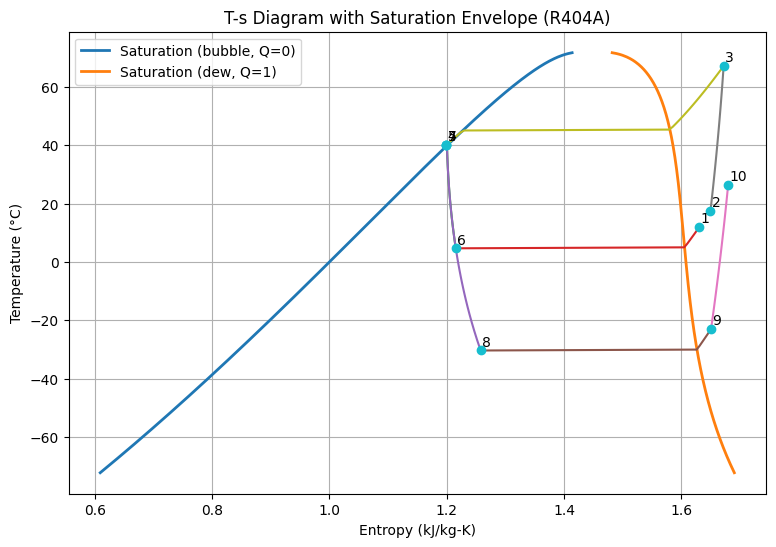

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# --- helpers (reuse your REF, props_PH, etc.) ---
def Ts_from_PH(P, h, REF):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def build_sat_dome(REF, N=500):
    Tmin = PropsSI("Tmin", REF) + 1.0
    Tcrit = PropsSI("Tcrit", REF) - 0.5
    Ts = np.linspace(Tmin, Tcrit, N)

    s_bub, T_bub = [], []
    s_dew, T_dew = [], []

    for T in Ts:
        # bubble line (Q=0)
        try:
            sb = PropsSI("S", "T", T, "Q", 0, REF)
            s_bub.append(sb); T_bub.append(T)
        except:
            pass

        # dew line (Q=1)
        try:
            sd = PropsSI("S", "T", T, "Q", 1, REF)
            s_dew.append(sd); T_dew.append(T)
        except:
            pass

    # convert to plotting units
    s_bub = np.array(s_bub)/1000.0
    s_dew = np.array(s_dew)/1000.0
    T_bub = np.array(T_bub) - 273.15
    T_dew = np.array(T_dew) - 273.15
    return (s_bub, T_bub), (s_dew, T_dew)

def path_isenthalpic(Pa, Pb, h, REF, N=60):
    Ps = np.linspace(Pa, Pb, N)
    ss, TT = [], []
    for P in Ps:
        T, s = Ts_from_PH(P, h, REF)
        ss.append(s/1000.0); TT.append(T - 273.15)
    return np.array(ss), np.array(TT)

def path_isobaric(P, ha, hb, REF, N=80):
    hs = np.linspace(ha, hb, N)
    ss, TT = [], []
    for h in hs:
        T, s = Ts_from_PH(P, h, REF)
        ss.append(s/1000.0); TT.append(T - 273.15)
    return np.array(ss), np.array(TT)

def path_compressor_eta(Pa, Pb, h_in, s_in, eta_is, REF, N=60):
    Ps = np.linspace(Pa, Pb, N)
    ss, TT = [], []
    for P in Ps:
        h_s = PropsSI("H", "P", P, "S", s_in, REF)          # isentropic h at this P
        h   = h_in + (h_s - h_in)/eta_is                    # actual h using eta
        T, s = Ts_from_PH(P, h, REF)
        ss.append(s/1000.0); TT.append(T - 273.15)
    return np.array(ss), np.array(TT)

# --- build dome ---
(bub, dew) = build_sat_dome(REF)
s_bub, T_bub = bub
s_dew, T_dew = dew

# --- extract your states from df (df already built above) ---
st = df.set_index("State")

def S(state): return st.loc[state, "s_kJkgK"]
def T(state): return st.loc[state, "T_C"]
def P(state): return st.loc[state, "P_bar"]*1e5
def H(state): return st.loc[state, "h_kJkg"]*1000
def S_SI(state): return st.loc[state, "s_kJkgK"]*1000

# --- plot ---
plt.figure(figsize=(9,6))

# saturation dome (bubble + dew)
plt.plot(s_bub, T_bub, linewidth=2, label="Saturation (bubble, Q=0)")
plt.plot(s_dew, T_dew, linewidth=2, label="Saturation (dew, Q=1)")

# --- Paths (sampled, physics-aware) ---

# 5->6 throttle (MT)
s56, T56 = path_isenthalpic(P(5), P(6), H(5), REF)
plt.plot(s56, T56)

# 6->1 evap MT (isobaric, includes 2-phase + superheat)
s61, T61 = path_isobaric(P(6), H(6), H(1), REF)
plt.plot(s61, T61)

# 7->8 throttle (LT)
s78, T78 = path_isenthalpic(P(7), P(8), H(7), REF)
plt.plot(s78, T78)

# 8->9 evap LT (isobaric)
s89, T89 = path_isobaric(P(8), H(8), H(9), REF)
plt.plot(s89, T89)

# 9->10 compressor 2 (eta-based path)
s910, T910 = path_compressor_eta(P(9), P(10), H(9), S_SI(9), eta_is_2, REF)
plt.plot(s910, T910)

# 2->3 compressor 1 (eta-based path)
s23, T23 = path_compressor_eta(P(2), P(3), H(2), S_SI(2), eta_is_1, REF)
plt.plot(s23, T23)

# 3->4 condenser (isobaric, will include 2-phase + subcool)
s34, T34 = path_isobaric(P(3), H(3), H(4), REF)
plt.plot(s34, T34)

# --- plot points + labels ---
plt.plot(df["s_kJkgK"], df["T_C"], marker="o", linestyle="None")

for _, r in df.iterrows():
    plt.text(r["s_kJkgK"] + 0.002, r["T_C"] + 1.5, str(int(r["State"])))

plt.xlabel("Entropy (kJ/kg-K)")
plt.ylabel("Temperature (°C)")
plt.title(f"T-s Diagram with Saturation Envelope ({REF})")
plt.grid(True)
plt.legend()
plt.show()


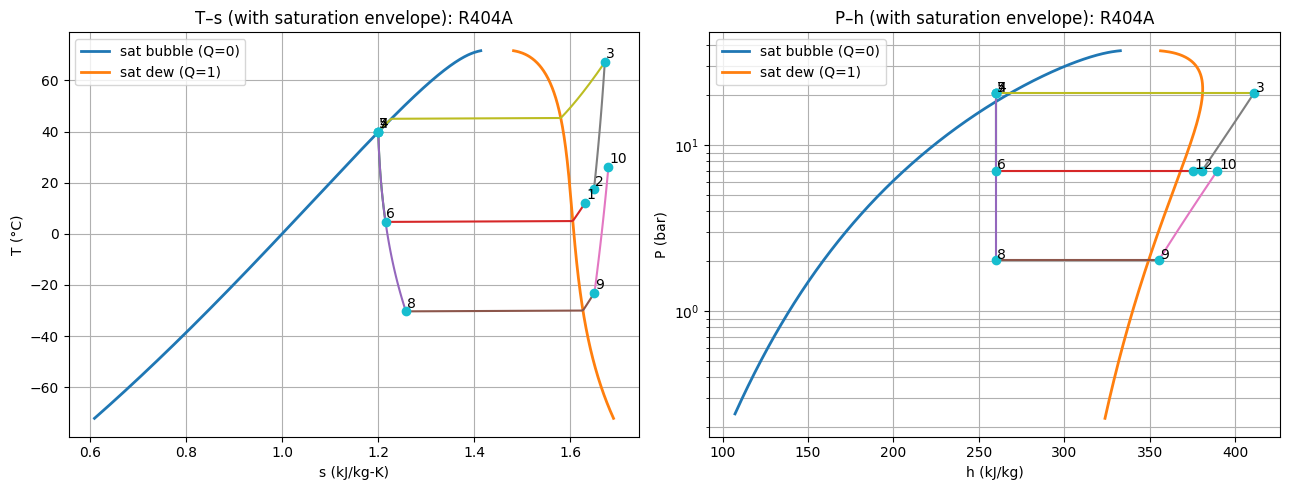

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# -------------------------
# Helpers
# -------------------------
def Ts_from_PH(P, h, REF):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def build_sat_Ts(REF, N=500):
    Tmin  = PropsSI("Tmin", REF) + 1.0
    Tcrit = PropsSI("Tcrit", REF) - 0.5
    Ts = np.linspace(Tmin, Tcrit, N)

    s_bub, T_bub, s_dew, T_dew = [], [], [], []
    for T in Ts:
        try:
            s_bub.append(PropsSI("S", "T", T, "Q", 0, REF)); T_bub.append(T)
        except: pass
        try:
            s_dew.append(PropsSI("S", "T", T, "Q", 1, REF)); T_dew.append(T)
        except: pass

    return (np.array(s_bub)/1000.0, np.array(T_bub)-273.15), (np.array(s_dew)/1000.0, np.array(T_dew)-273.15)

def build_sat_Ph(REF, N=500):
    Tmin  = PropsSI("Tmin", REF) + 1.0
    Tcrit = PropsSI("Tcrit", REF) - 0.5
    Ts = np.linspace(Tmin, Tcrit, N)

    h_bub, P_bub, h_dew, P_dew = [], [], [], []
    for T in Ts:
        # For blends, bubble and dew are distinct (and that’s why your plot looked wrong earlier).
        try:
            P0 = PropsSI("P", "T", T, "Q", 0, REF)
            h0 = PropsSI("H", "T", T, "Q", 0, REF)
            P_bub.append(P0); h_bub.append(h0)
        except: pass
        try:
            P1 = PropsSI("P", "T", T, "Q", 1, REF)
            h1 = PropsSI("H", "T", T, "Q", 1, REF)
            P_dew.append(P1); h_dew.append(h1)
        except: pass

    return (np.array(h_bub)/1000.0, np.array(P_bub)/1e5), (np.array(h_dew)/1000.0, np.array(P_dew)/1e5)

def path_isenthalpic(Pa, Pb, h, REF, N=60):
    Ps = np.linspace(Pa, Pb, N)
    s_list, T_list, P_list, h_list = [], [], [], []
    for P in Ps:
        T, s = Ts_from_PH(P, h, REF)
        s_list.append(s/1000.0); T_list.append(T-273.15)
        P_list.append(P/1e5);    h_list.append(h/1000.0)
    return np.array(s_list), np.array(T_list), np.array(P_list), np.array(h_list)

def path_isobaric(P, ha, hb, REF, N=80):
    hs = np.linspace(ha, hb, N)
    s_list, T_list, P_list, h_list = [], [], [], []
    for h in hs:
        T, s = Ts_from_PH(P, h, REF)
        s_list.append(s/1000.0); T_list.append(T-273.15)
        P_list.append(P/1e5);    h_list.append(h/1000.0)
    return np.array(s_list), np.array(T_list), np.array(P_list), np.array(h_list)

def path_compressor_eta(Pa, Pb, h_in, s_in, eta_is, REF, N=60):
    Ps = np.linspace(Pa, Pb, N)
    s_list, T_list, P_list, h_list = [], [], [], []
    for P in Ps:
        h_s = PropsSI("H", "P", P, "S", s_in, REF)
        h   = h_in + (h_s - h_in)/eta_is
        T, s = Ts_from_PH(P, h, REF)
        s_list.append(s/1000.0); T_list.append(T-273.15)
        P_list.append(P/1e5);    h_list.append(h/1000.0)
    return np.array(s_list), np.array(T_list), np.array(P_list), np.array(h_list)

# -------------------------
# Pull your state values from df
# -------------------------
st = df.set_index("State")
def P_SI(i): return float(st.loc[i, "P_bar"]*1e5)
def H_SI(i): return float(st.loc[i, "h_kJkg"]*1000)
def S_SI(i): return float(st.loc[i, "s_kJkgK"]*1000)

# -------------------------
# Build envelopes
# -------------------------
(s_bub, T_bub), (s_dew, T_dew) = build_sat_Ts(REF, N=600)
(h_bub, P_bub), (h_dew, P_dew) = build_sat_Ph(REF, N=600)

# -------------------------
# Build process paths (sampled)
# -------------------------
paths = []

# 5->6 throttle MT
paths.append(path_isenthalpic(P_SI(5), P_SI(6), H_SI(5), REF, N=80))
# 6->1 evap MT
paths.append(path_isobaric(P_SI(6), H_SI(6), H_SI(1), REF, N=120))

# 7->8 throttle LT
paths.append(path_isenthalpic(P_SI(7), P_SI(8), H_SI(7), REF, N=80))
# 8->9 evap LT
paths.append(path_isobaric(P_SI(8), H_SI(8), H_SI(9), REF, N=120))

# 9->10 compressor 2
paths.append(path_compressor_eta(P_SI(9), P_SI(10), H_SI(9), S_SI(9), eta_is_2, REF, N=80))
# 2->3 compressor 1
paths.append(path_compressor_eta(P_SI(2), P_SI(3), H_SI(2), S_SI(2), eta_is_1, REF, N=80))

# 3->4 condenser
paths.append(path_isobaric(P_SI(3), H_SI(3), H_SI(4), REF, N=160))

# -------------------------
# Plot: T-s and P-h
# -------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# --- T-s ---
ax[0].plot(s_bub, T_bub, linewidth=2, label="sat bubble (Q=0)")
ax[0].plot(s_dew, T_dew, linewidth=2, label="sat dew (Q=1)")

for s_path, T_path, P_path, h_path in paths:
    ax[0].plot(s_path, T_path)

ax[0].plot(df["s_kJkgK"], df["T_C"], marker="o", linestyle="None")
for _, r in df.iterrows():
    ax[0].text(r["s_kJkgK"] + 0.002, r["T_C"] + 1.5, str(int(r["State"])))

ax[0].set_xlabel("s (kJ/kg-K)")
ax[0].set_ylabel("T (°C)")
ax[0].set_title(f"T–s (with saturation envelope): {REF}")
ax[0].grid(True)
ax[0].legend()

# --- P-h ---
ax[1].plot(h_bub, P_bub, linewidth=2, label="sat bubble (Q=0)")
ax[1].plot(h_dew, P_dew, linewidth=2, label="sat dew (Q=1)")

for s_path, T_path, P_path, h_path in paths:
    ax[1].plot(h_path, P_path)

ax[1].plot(df["h_kJkg"], df["P_bar"], marker="o", linestyle="None")
for _, r in df.iterrows():
    ax[1].text(r["h_kJkg"] + 1.0, r["P_bar"] * 1.02, str(int(r["State"])))

ax[1].set_yscale("log")  # P-h diagrams are basically always log(P)
ax[1].set_xlabel("h (kJ/kg)")
ax[1].set_ylabel("P (bar)")
ax[1].set_title(f"P–h (with saturation envelope): {REF}")
ax[1].grid(True, which="both")
ax[1].legend()

plt.tight_layout()
plt.show()


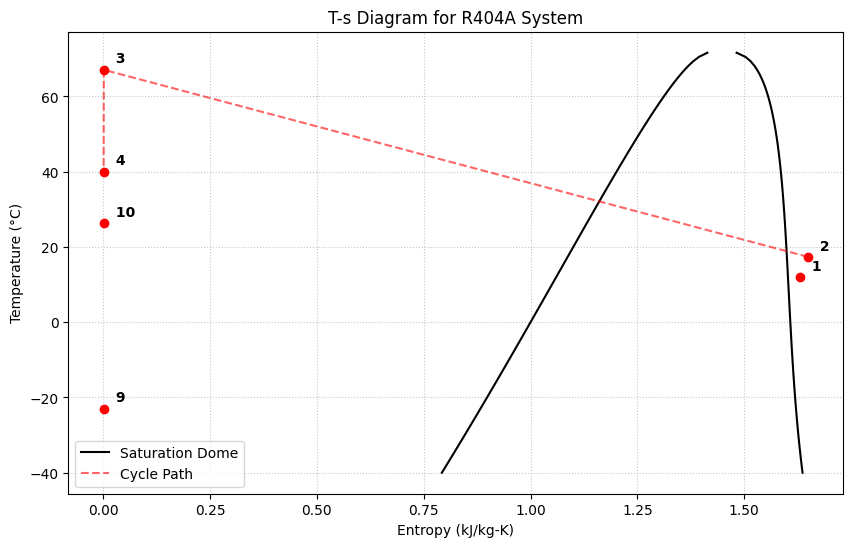

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# 1. SETUP & SIMULATION (Keep your original logic)
# =========================
REF = "R404A"
Te_MT_C, Te_LT_C, Tc_C = 5.0, -30.0, 45.0
dTsh_MT, dTsh_LT, dTsc = 7.0, 7.0, 5.0
eta_is_1, eta_is_2 = 0.75, 0.75
Q_MT_kW, Q_LT_kW = 100.0, 50.0

def C_to_K(Tc): return Tc + 273.15
def K_to_C(Tk): return Tk - 273.15

Te_MT, Te_LT, Tc = C_to_K(Te_MT_C), C_to_K(Te_LT_C), C_to_K(Tc_C)
P_i = PropsSI("P", "T", Te_MT, "Q", 1, REF)
P_l = PropsSI("P", "T", Te_LT, "Q", 1, REF)
P_h = PropsSI("P", "T", Tc, "Q", 0, REF)

# State Calculations
h4 = PropsSI("H", "T", Tc - dTsc, "P", P_h, REF)
s4 = PropsSI("S", "T", Tc - dTsc, "P", P_h, REF)
h1 = PropsSI("H", "T", Te_MT + dTsh_MT, "P", P_i, REF)
s1 = PropsSI("S", "T", Te_MT + dTsh_MT, "P", P_i, REF)
h9 = PropsSI("H", "T", Te_LT + dTsh_LT, "P", P_l, REF)
s9 = PropsSI("S", "T", Te_LT + dTsh_LT, "P", P_l, REF)

# Mass flows
m_MT = (Q_MT_kW * 1000) / (h1 - h4)
m_LT = (Q_LT_kW * 1000) / (h9 - h4)
m_tot = m_MT + m_LT

# Compression & Mixing
h10s = PropsSI("H", "P", P_i, "S", s9, REF)
h10 = h9 + (h10s - h9)/eta_is_2
h2 = (m_MT*h1 + m_LT*h10)/m_tot
s2 = PropsSI("S", "P", P_i, "H", h2, REF)
h3s = PropsSI("H", "P", P_h, "S", s2, REF)
h3 = h2 + (h3s - h2)/eta_is_1

# Collect states for plotting
states = {
    1: (s1, K_to_C(Te_MT + dTsh_MT)),
    2: (s2, PropsSI("T", "P", P_i, "H", h2, REF) - 273.15),
    3: (PropsSI("S", "P", P_h, "H", h3, REF)/1000, PropsSI("T", "P", P_h, "H", h3, REF) - 273.15),
    4: (s4/1000, Tc_C - dTsc),
    9: (s9/1000, Te_LT_C + dTsh_LT),
    10: (PropsSI("S", "P", P_i, "H", h10, REF)/1000, PropsSI("T", "P", P_i, "H", h10, REF) - 273.15)
}
df_plot = pd.DataFrame.from_dict(states, orient='index', columns=['s', 'T'])
df_plot['s'] = df_plot['s'] / (1 if df_plot['s'].max() < 10 else 1000) # Ensure kJ/kgK

# =========================
# 2. GENERATE DOME DATA
# =========================
T_crit = PropsSI("T_CRITICAL", REF)
T_min = C_to_K(Te_LT_C - 10)
T_range = np.linspace(T_min, T_crit - 0.5, 100)

s_liq = [PropsSI("S", "T", t, "Q", 0, REF) / 1000 for t in T_range]
s_vap = [PropsSI("S", "T", t, "Q", 1, REF) / 1000 for t in T_range]
T_dome = [K_to_C(t) for t in T_range]

# =========================
# 3. PLOTTING
# =========================
plt.figure(figsize=(10, 6))

# Plot Saturation Dome
plt.plot(s_liq, T_dome, 'k-', linewidth=1.5, label="Saturation Dome")
plt.plot(s_vap, T_dome, 'k-', linewidth=1.5)

# Plot State Points
plt.scatter(df_plot['s'], df_plot['T'], color='red', zorder=5)

# Add Labels with offsets
for i, row in df_plot.iterrows():
    plt.annotate(f" {i}", (row['s'], row['T']), textcoords="offset points", xytext=(5,5), fontweight='bold')

# Connect common cycle paths (visual aid)
# High side loop example
plt.plot(df_plot.loc[[2,3,4], 's'], df_plot.loc[[2,3,4], 'T'], 'r--', alpha=0.6, label="Cycle Path")



plt.title(f"T-s Diagram for {REF} System")
plt.xlabel("Entropy (kJ/kg-K)")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

 dTsh      COP       x6       x8
    0 2.447643 0.330799 0.529648
    2 2.459957 0.330799 0.529648
    4 2.472341 0.330799 0.529648
    6 2.484784 0.330799 0.529648
    8 2.497274 0.330799 0.529648
   10 2.509804 0.330799 0.529648
   12 2.522366 0.330799 0.529648
   14 2.534953 0.330799 0.529648
   16 2.547560 0.330799 0.529648
   18 2.560182 0.330799 0.529648
   20 2.572816 0.330799 0.529648


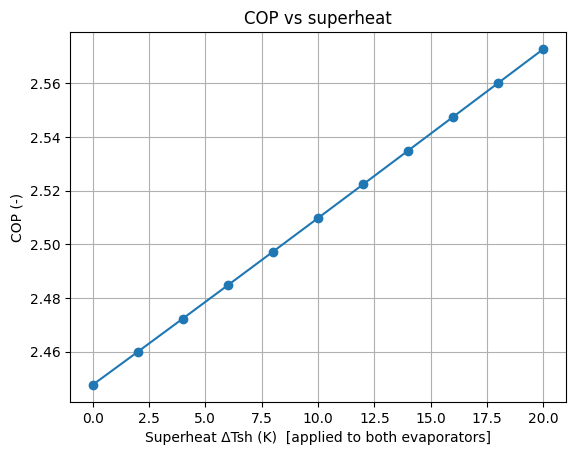

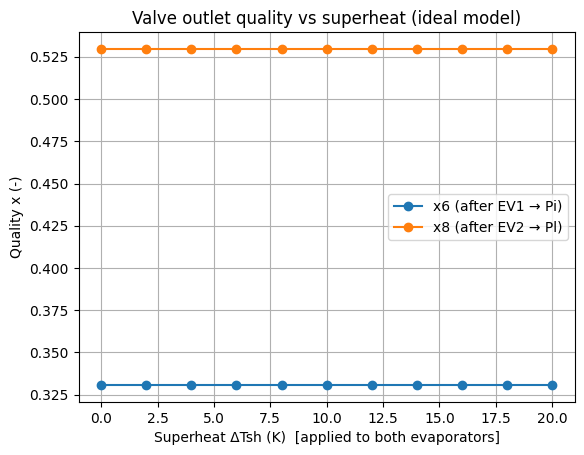

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# FIXED INPUTS
# =========================
REF = "R404A"

Te_MT_C = 5.0       # Evap-1 SST (°C)
Te_LT_C = -30.0     # Evap-2 SST (°C)
Tc_C    = 45.0      # Condensing temperature (°C)

dTsc    = 5.0       # subcooling after condenser (K)

eta_is_1 = 0.75
eta_is_2 = 0.75

Q_MT_kW = 100.0
Q_LT_kW = 50.0

# Superheat sweep (K)
dTsh_list = list(range(0, 21, 2))  # 0K to 20K

# =========================
# HELPERS
# =========================
def C_to_K(Tc): return Tc + 273.15
def kW_to_W(x): return x * 1000.0

def Psat_from_T(T, Q):
    # Q=0 bubble, Q=1 dew
    return PropsSI("P", "T", T, "Q", Q, REF)

def props_TP(T, P):
    h = PropsSI("H", "T", T, "P", P, REF)
    s = PropsSI("S", "T", T, "P", P, REF)
    return h, s

def props_PH(P, h):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def H_from_PS(P, s):
    return PropsSI("H", "P", P, "S", s, REF)

def safe_quality_PH(P, h):
    try:
        x = PropsSI("Q", "P", P, "H", h, REF)
        if math.isnan(x) or x < 0 or x > 1:
            return None
        return float(x)
    except Exception:
        return None

# =========================
# BASE TEMPS/LOADS
# =========================
Te_MT = C_to_K(Te_MT_C)
Te_LT = C_to_K(Te_LT_C)
Tc    = C_to_K(Tc_C)

Q_MT = kW_to_W(Q_MT_kW)
Q_LT = kW_to_W(Q_LT_kW)

# Pressures from SST/SDT (independent of superheat)
P_i = Psat_from_T(Te_MT, Q=1)  # dew at evap outlet (common for blends)
P_l = Psat_from_T(Te_LT, Q=1)
P_h = Psat_from_T(Tc,    Q=0)  # bubble at condenser

# Condenser outlet (independent of superheat)
T4 = Tc - dTsc
h4, s4 = props_TP(T4, P_h)

# Throttle outlet enthalpies fixed (independent of superheat)
h6 = h4
h8 = h4

# Qualities after valves (these will be ~constant in this ideal model)
x6_const = safe_quality_PH(P_i, h6)
x8_const = safe_quality_PH(P_l, h8)

# =========================
# SWEEP SUPERHEAT
# =========================
records = []

for dTsh in dTsh_list:
    # Evap outlets
    T1 = Te_MT + dTsh
    T9 = Te_LT + dTsh

    # Handle the specific case of dTsh = 0 for blend properties
    if dTsh == 0:
        h1 = PropsSI("H", "T", Te_MT, "Q", 1, REF) # Use T and Q for saturated vapor
        s1 = PropsSI("S", "T", Te_MT, "Q", 1, REF)
        h9 = PropsSI("H", "T", Te_LT, "Q", 1, REF) # Use T and Q for saturated vapor
        s9 = PropsSI("S", "T", Te_LT, "Q", 1, REF)
    else:
        h1, s1 = props_TP(T1, P_i)
        h9, s9 = props_TP(T9, P_l)

    # Mass flows from fixed loads
    dH_MT = h1 - h6
    dH_LT = h9 - h8
    if dH_MT <= 0 or dH_LT <= 0:
        records.append({"dTsh": dTsh, "COP": float("nan"), "x6": x6_const, "x8": x8_const})
        continue

    m_MT = Q_MT / dH_MT
    m_LT = Q_LT / dH_LT
    m_tot = m_MT + m_LT

    # Compressor 2: 9 -> 10 (to P_i)
    h10s = H_from_PS(P_i, s9)
    h10  = h9 + (h10s - h9) / eta_is_2

    # Mixer: (1 and 10) -> 2 at P_i
    h2 = (m_MT*h1 + m_LT*h10) / m_tot
    T2, s2 = props_PH(P_i, h2)

    # Compressor 1: 2 -> 3 (to P_h)
    h3s = H_from_PS(P_h, s2)
    h3  = h2 + (h3s - h2) / eta_is_1

    # Powers and COP
    W2 = m_LT  * (h10 - h9)
    W1 = m_tot * (h3  - h2)
    COP = (Q_MT + Q_LT) / (W1 + W2)

    records.append({"dTsh": dTsh, "COP": COP, "x6": x6_const, "x8": x8_const})

df = pd.DataFrame(records)
print(df.to_string(index=False))

# =========================
# PLOTS (default matplotlib colors)
# =========================
plt.figure()
plt.plot(df["dTsh"], df["COP"], marker="o")
plt.xlabel("Superheat ΔTsh (K)  [applied to both evaporators]")
plt.ylabel("COP (-)")
plt.title("COP vs superheat")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["dTsh"], df["x6"], marker="o", label="x6 (after EV1 → Pi)")
plt.plot(df["dTsh"], df["x8"], marker="o", label="x8 (after EV2 → Pl)")
plt.xlabel("Superheat ΔTsh (K)  [applied to both evaporators]")
plt.ylabel("Quality x (-)")
plt.title("Valve outlet quality vs superheat (ideal model)")
plt.grid(True)
plt.legend()
plt.show()



=== Parametric study results (Tc sweep) ===
 Tc_C   P_h_bar     m_MT     m_LT    m_tot  PR_hi_int  PR_hi_low
   35 16.196061 0.760424 0.448735 1.209159   2.307801   8.008585
   37 17.012674 0.778945 0.461691 1.240636   2.424161   8.412382
   39 17.859992 0.798598 0.475565 1.274164   2.544897   8.831361
   41 18.738859 0.819501 0.490465 1.309967   2.670128   9.265941
   43 19.650155 0.841787 0.506516 1.348304   2.799980   9.716556
   45 20.594795 0.865611 0.523867 1.389478   2.934583  10.183659
   47 21.573739 0.891150 0.542693 1.433843   3.074074  10.667725
   49 22.587997 0.918615 0.563201 1.481816   3.218597  11.169253
   51 23.638641 0.948250 0.585644 1.533894   3.368305  11.688772
   53 24.726815 0.980347 0.610327 1.590673   3.523360  12.226850
   55 25.853758 1.015251 0.637621 1.652872   3.683940  12.784097

Saved: parametric_Tc_results.csv


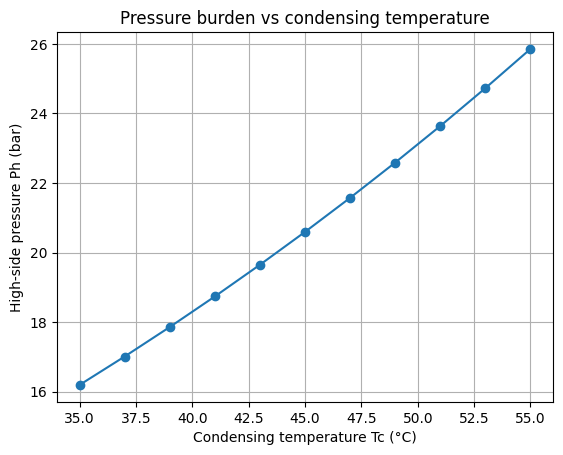

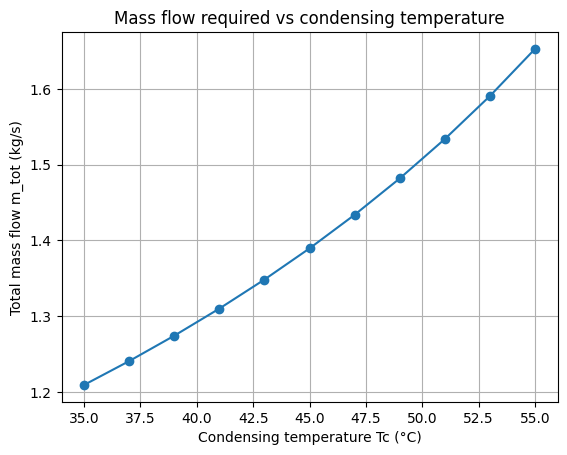

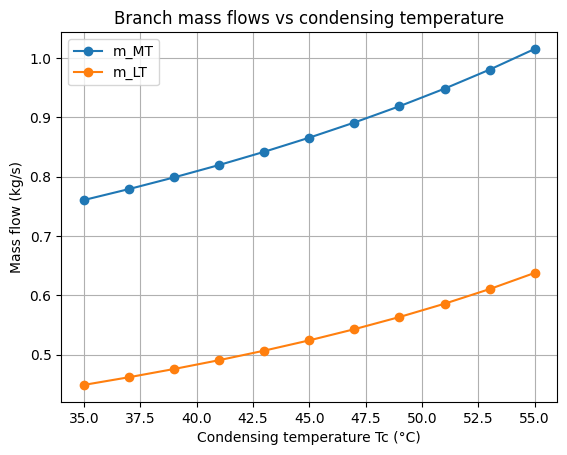

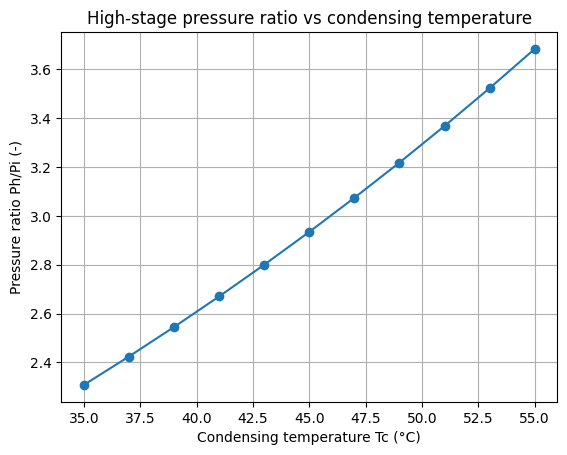

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# FIXED INPUTS (keep constant in study)
# =========================
REF = "R404A"      # change if assigned

# Evaporator saturation temperatures (SST)
Te_MT_C = 5.0      # Evap-1 SST (°C)
Te_LT_C = -30.0    # Evap-2 SST (°C)

# Superheat and subcooling
dTsh_MT = 7.0      # K
dTsh_LT = 7.0      # K
dTsc    = 5.0      # K

# Compressor isentropic efficiencies
eta_is_1 = 0.75
eta_is_2 = 0.75

# Loads (fixed)
Q_MT_kW = 100.0
Q_LT_kW = 50.0

# Condensing temperature sweep (°C)
Tc_list_C = list(range(35, 56, 2))  # 35°C to 55°C in steps of 2°C

# =========================
# Helpers
# =========================
def C_to_K(Tc): return Tc + 273.15
def kW_to_W(x): return x * 1000.0

def Psat_from_T(T, Q):
    # Q=0 bubble, Q=1 dew
    return PropsSI("P", "T", T, "Q", Q, REF)

def props_TP(T, P):
    h = PropsSI("H", "T", T, "P", P, REF)
    s = PropsSI("S", "T", T, "P", P, REF)
    return h, s

def props_PH(P, h):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def H_from_PS(P, s):
    return PropsSI("H", "P", P, "S", s, REF)

# =========================
# Fixed conversions
# =========================
Te_MT = C_to_K(Te_MT_C)
Te_LT = C_to_K(Te_LT_C)
Q_MT = kW_to_W(Q_MT_kW)
Q_LT = kW_to_W(Q_LT_kW)

# Pressures set by SSTs (do NOT assume both T and P)
P_i = Psat_from_T(Te_MT, Q=1)  # dew @ evap outlet
P_l = Psat_from_T(Te_LT, Q=1)

# Evap outlet temps (superheated)
T1 = Te_MT + dTsh_MT
T9 = Te_LT + dTsh_LT

# Precompute evap outlet properties that don't change with Tc
h1, s1 = props_TP(T1, P_i)
h9, s9 = props_TP(T9, P_l)

# =========================
# Sweep Tc
# =========================
records = []

for Tc_C in Tc_list_C:
    Tc = C_to_K(Tc_C)

    # High-side pressure from condensing temperature
    P_h = Psat_from_T(Tc, Q=0)   # bubble at condenser

    # State 4: subcooled liquid
    T4 = Tc - dTsc
    h4, s4 = props_TP(T4, P_h)

    # Split lines: 5 and 7 are before valves (same as 4)
    h5 = h4
    h7 = h4

    # Throttles: isoenthalpic
    # 5 -> 6 to P_i
    h6 = h5
    T6, s6 = props_PH(P_i, h6)

    # 7 -> 8 to P_l
    h8 = h7
    T8, s8 = props_PH(P_l, h8)

    # Mass flows from fixed loads
    # (If h1-h6 becomes tiny/negative due to impossible operating point, skip)
    dH_MT = (h1 - h6)
    dH_LT = (h9 - h8)
    if dH_MT <= 0 or dH_LT <= 0:
        records.append({
            "Tc_C": Tc_C,
            "P_h_bar": P_h/1e5,
            "m_MT": float("nan"),
            "m_LT": float("nan"),
            "m_tot": float("nan"),
            "PR_hi_int": P_h/P_i,
            "PR_hi_low": P_h/P_l
        })
        continue

    m_MT = Q_MT / dH_MT
    m_LT = Q_LT / dH_LT
    m_tot = m_MT + m_LT

    # (Optional) pressure ratios as "burden"
    PR_hi_int = P_h / P_i
    PR_hi_low = P_h / P_l

    records.append({
        "Tc_C": Tc_C,
        "P_h_bar": P_h/1e5,
        "m_MT": m_MT,
        "m_LT": m_LT,
        "m_tot": m_tot,
        "PR_hi_int": PR_hi_int,
        "PR_hi_low": PR_hi_low
    })

df = pd.DataFrame(records)

print("\n=== Parametric study results (Tc sweep) ===")
print(df.to_string(index=False))

# Save results
df.to_csv("parametric_Tc_results.csv", index=False)
print("\nSaved: parametric_Tc_results.csv")

# =========================
# Plots (no custom colors)
# =========================
plt.figure()
plt.plot(df["Tc_C"], df["P_h_bar"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("High-side pressure Ph (bar)")
plt.title("Pressure burden vs condensing temperature")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["Tc_C"], df["m_tot"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Total mass flow m_tot (kg/s)")
plt.title("Mass flow required vs condensing temperature")
plt.grid(True)
plt.show()

# Optional: show branch mass flows too
plt.figure()
plt.plot(df["Tc_C"], df["m_MT"], marker="o", label="m_MT")
plt.plot(df["Tc_C"], df["m_LT"], marker="o", label="m_LT")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Mass flow (kg/s)")
plt.title("Branch mass flows vs condensing temperature")
plt.grid(True)
plt.legend()
plt.show()

# Optional: pressure ratio plots (if you want 'burden' to sound fancier)
plt.figure()
plt.plot(df["Tc_C"], df["PR_hi_int"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Pressure ratio Ph/Pi (-)")
plt.title("High-stage pressure ratio vs condensing temperature")
plt.grid(True)
plt.show()



=== Tc Sensitivity results ===
 Tc_C   P_h_bar     m_MT     m_LT    m_tot  PR_hi_int  PR_hi_low     W1_kW     W2_kW   Wtot_kW      COP   Qcond_kW       x6       x8
   35 16.196061 0.760424 0.448735 1.209159   2.307801   8.008585 28.645014 15.420991 44.066005 3.403985 194.066005 0.232126 0.445690
   37 17.012674 0.778945 0.461691 1.240636   2.424161   8.412382 31.100007 15.866228 46.966235 3.193784 196.966235 0.251433 0.462118
   39 17.859992 0.798598 0.475565 1.274164   2.544897   8.831361 33.670295 16.343013 50.013308 2.999202 200.013308 0.270942 0.478717
   41 18.738859 0.819501 0.490465 1.309967   2.670128   9.265941 36.368850 16.855049 53.223899 2.818283 203.223899 0.290664 0.495498
   43 19.650155 0.841787 0.506516 1.348304   2.799980   9.716556 39.210686 17.406659 56.617345 2.649365 206.617345 0.310611 0.512471
   45 20.594795 0.865611 0.523867 1.389478   2.934583  10.183659 42.213283 18.002927 60.216210 2.491024 210.216210 0.330799 0.529648
   47 21.573739 0.891150 0.542693 1.4

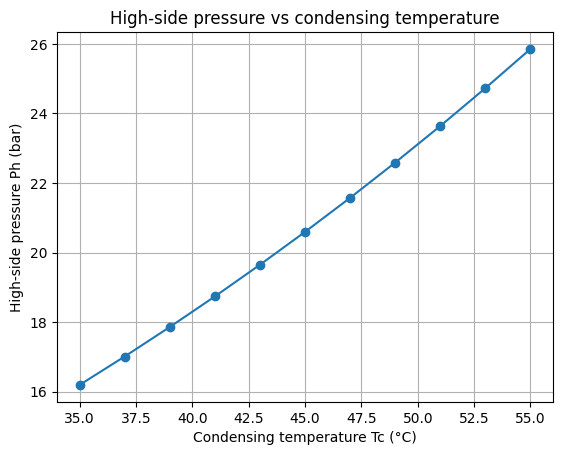

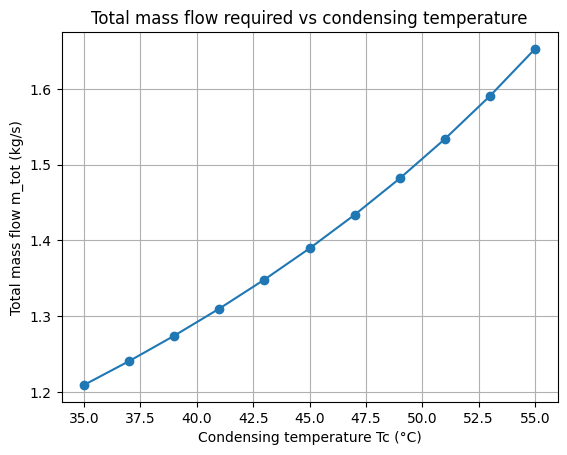

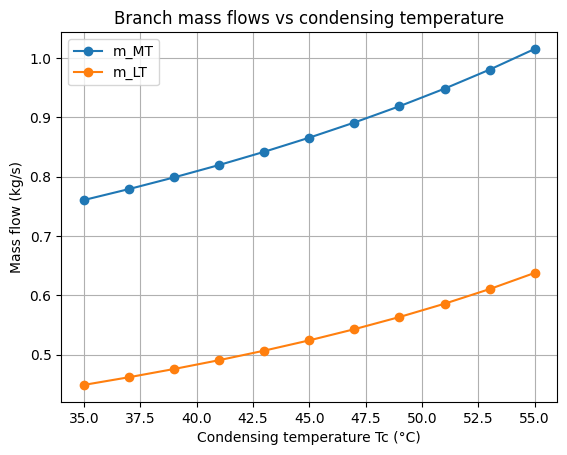

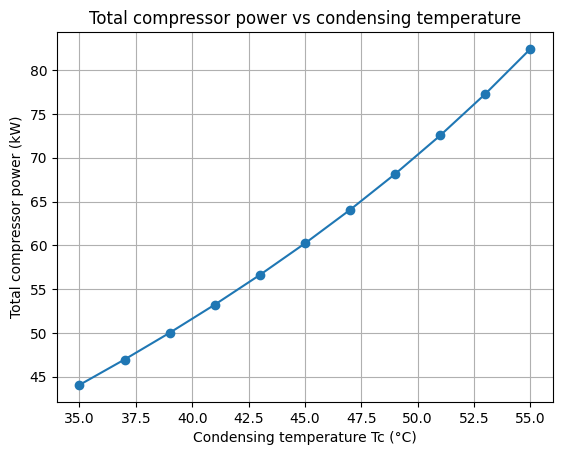

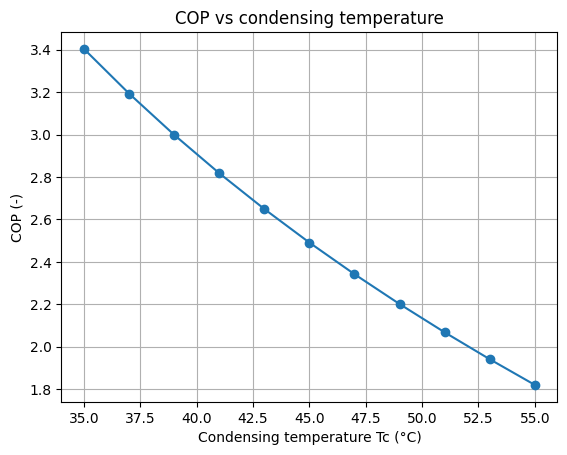

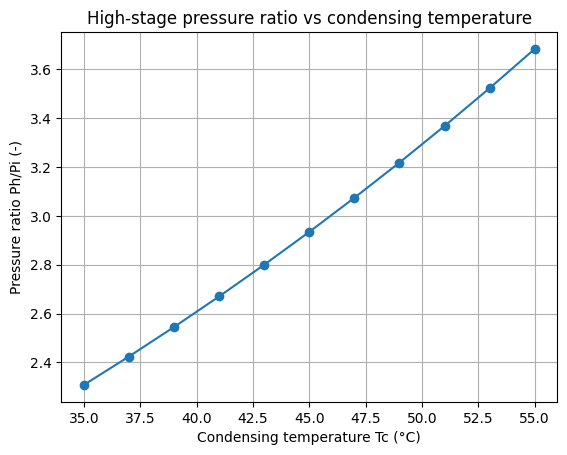

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# FIXED INPUTS (constant in study)
# =========================
REF = "R404A"

# Evaporator saturation temperatures (SST)
Te_MT_C = 5.0      # Evap-1 SST (°C)
Te_LT_C = -30.0    # Evap-2 SST (°C)

# Superheat and subcooling
dTsh_MT = 7.0      # K
dTsh_LT = 7.0      # K
dTsc    = 5.0      # K

# Compressor isentropic efficiencies
eta_is_1 = 0.75    # Compressor 1 (2->3)
eta_is_2 = 0.75    # Compressor 2 (9->10)

# Loads (fixed)
Q_MT_kW = 100.0
Q_LT_kW = 50.0

# Condensing temperature sweep (°C)
Tc_list_C = list(range(35, 56, 2))  # 35°C to 55°C, step 2°C

# =========================
# Helpers
# =========================
def C_to_K(Tc): return Tc + 273.15
def K_to_C(Tk): return Tk - 273.15
def kW_to_W(x): return x * 1000.0

def Psat_from_T(T, Q):
    # Q=0 bubble, Q=1 dew
    return PropsSI("P", "T", T, "Q", Q, REF)

def props_TP(T, P):
    h = PropsSI("H", "T", T, "P", P, REF)
    s = PropsSI("S", "T", T, "P", P, REF)
    return h, s

def props_PH(P, h):
    T = PropsSI("T", "P", P, "H", h, REF)
    s = PropsSI("S", "P", P, "H", h, REF)
    return T, s

def H_from_PS(P, s):
    return PropsSI("H", "P", P, "S", s, REF)

def safe_quality_PH(P, h):
    try:
        x = PropsSI("Q", "P", P, "H", h, REF)
        if math.isnan(x) or x < 0 or x > 1:
            return None
        return float(x)
    except Exception:
        return None

# =========================
# Fixed conversions
# =========================
Te_MT = C_to_K(Te_MT_C)
Te_LT = C_to_K(Te_LT_C)

Q_MT = kW_to_W(Q_MT_kW)
Q_LT = kW_to_W(Q_LT_kW)
Q_tot = Q_MT + Q_LT

# Pressures set by SSTs (use dew at evap outlet for blends)
P_i = Psat_from_T(Te_MT, Q=1)  # intermediate / MT evap pressure
P_l = Psat_from_T(Te_LT, Q=1)  # low / LT evap pressure

# Evap outlet temps (superheated)
T1 = Te_MT + dTsh_MT
T9 = Te_LT + dTsh_LT

# Evap outlet properties that do NOT change with Tc
h1, s1 = props_TP(T1, P_i)
h9, s9 = props_TP(T9, P_l)

# =========================
# Sweep Tc
# =========================
records = []

for Tc_C in Tc_list_C:
    Tc = C_to_K(Tc_C)

    try:
        # High-side pressure from condensing temperature (bubble for condenser outlet reference)
        P_h = Psat_from_T(Tc, Q=0)

        # State 4: condenser outlet (subcooled/compressed liquid)
        T4 = Tc - dTsc
        h4, s4 = props_TP(T4, P_h)

        # Split lines: 5 and 7 are before valves (same as 4)
        h5 = h4
        h7 = h4

        # Throttles: isoenthalpic
        # 5 -> 6 to P_i
        h6 = h5
        T6, s6 = props_PH(P_i, h6)
        x6 = safe_quality_PH(P_i, h6)

        # 7 -> 8 to P_l
        h8 = h7
        T8, s8 = props_PH(P_l, h8)
        x8 = safe_quality_PH(P_l, h8)

        # Enthalpy lifts across evaporators (must be positive)
        dH_MT = h1 - h6
        dH_LT = h9 - h8

        if dH_MT <= 0 or dH_LT <= 0:
            # impossible operating point (e.g., too much subcooling/too high Tc, etc.)
            records.append({
                "Tc_C": Tc_C,
                "P_h_bar": P_h/1e5,
                "m_MT": np.nan,
                "m_LT": np.nan,
                "m_tot": np.nan,
                "PR_hi_int": P_h/P_i,
                "PR_hi_low": P_h/P_l,
                "W1_kW": np.nan,
                "W2_kW": np.nan,
                "Wtot_kW": np.nan,
                "COP": np.nan,
                "Qcond_kW": np.nan,
                "x6": x6,
                "x8": x8
            })
            continue

        # Mass flows from fixed loads
        m_MT = Q_MT / dH_MT
        m_LT = Q_LT / dH_LT
        m_tot = m_MT + m_LT

        # Pressure ratios (burden)
        PR_hi_int = P_h / P_i
        PR_hi_low = P_h / P_l

        # Compressor 2: 9 -> 10 to P_i
        P10 = P_i
        h10s = H_from_PS(P10, s9)
        h10  = h9 + (h10s - h9) / eta_is_2
        T10, s10 = props_PH(P10, h10)

        # Mixer: (1 and 10) -> 2 at P_i (adiabatic)
        P2 = P_i
        h2 = (m_MT*h1 + m_LT*h10) / m_tot
        T2, s2 = props_PH(P2, h2)

        # Compressor 1: 2 -> 3 to P_h
        P3 = P_h
        h3s = H_from_PS(P3, s2)
        h3  = h2 + (h3s - h2) / eta_is_1
        T3, s3 = props_PH(P3, h3)

        # Powers and COP
        W2 = m_LT * (h10 - h9)       # W
        W1 = m_tot * (h3 - h2)       # W
        Wtot = W1 + W2               # W
        COP = Q_tot / Wtot

        # Condenser heat rejection (sanity)
        Qcond = m_tot * (h3 - h4)    # W

        records.append({
            "Tc_C": Tc_C,
            "P_h_bar": P_h/1e5,
            "m_MT": m_MT,
            "m_LT": m_LT,
            "m_tot": m_tot,
            "PR_hi_int": PR_hi_int,
            "PR_hi_low": PR_hi_low,
            "W1_kW": W1/1000.0,
            "W2_kW": W2/1000.0,
            "Wtot_kW": Wtot/1000.0,
            "COP": COP,
            "Qcond_kW": Qcond/1000.0,
            "x6": x6,
            "x8": x8
        })

    except Exception:
        # CoolProp can throw if state goes out of range
        records.append({
            "Tc_C": Tc_C,
            "P_h_bar": np.nan,
            "m_MT": np.nan,
            "m_LT": np.nan,
            "m_tot": np.nan,
            "PR_hi_int": np.nan,
            "PR_hi_low": np.nan,
            "W1_kW": np.nan,
            "W2_kW": np.nan,
            "Wtot_kW": np.nan,
            "COP": np.nan,
            "Qcond_kW": np.nan,
            "x6": None,
            "x8": None
        })

df = pd.DataFrame(records)

print("\n=== Tc Sensitivity results ===")
print(df.to_string(index=False))

# Save results
out_csv = "sensitivity_Tc_results_with_COP.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

# =========================
# Plots (matplotlib defaults, no custom colors)
# =========================
df_plot = df.dropna(subset=["P_h_bar", "m_tot", "COP", "Wtot_kW"])

plt.figure()
plt.plot(df_plot["Tc_C"], df_plot["P_h_bar"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("High-side pressure Ph (bar)")
plt.title("High-side pressure vs condensing temperature")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df_plot["Tc_C"], df_plot["m_tot"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Total mass flow m_tot (kg/s)")
plt.title("Total mass flow required vs condensing temperature")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df_plot["Tc_C"], df_plot["m_MT"], marker="o", label="m_MT")
plt.plot(df_plot["Tc_C"], df_plot["m_LT"], marker="o", label="m_LT")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Mass flow (kg/s)")
plt.title("Branch mass flows vs condensing temperature")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(df_plot["Tc_C"], df_plot["Wtot_kW"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Total compressor power (kW)")
plt.title("Total compressor power vs condensing temperature")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df_plot["Tc_C"], df_plot["COP"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("COP (-)")
plt.title("COP vs condensing temperature")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df_plot["Tc_C"], df_plot["PR_hi_int"], marker="o")
plt.xlabel("Condensing temperature Tc (°C)")
plt.ylabel("Pressure ratio Ph/Pi (-)")
plt.title("High-stage pressure ratio vs condensing temperature")
plt.grid(True)
plt.show()
